<a href="https://colab.research.google.com/github/RevathiVersatile/electronic-device-failure-prediction/blob/main/ml_proj_elec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


DATASET PREVIEW

   temperature  voltage   current  vibration  failure
0           73      224  7.214648   1.375928        0
1           86      210  4.541739   3.313121        1
2           63      234  9.011815   1.143769        0
3           49      216  5.924680   2.862392        0
4           77      218  5.119111   3.170579        0


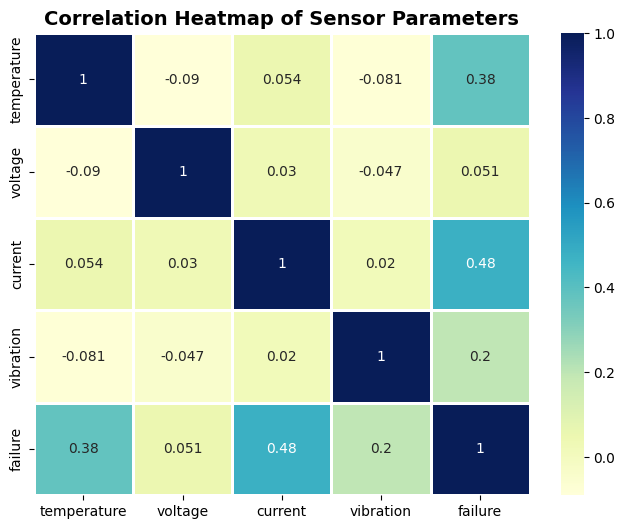

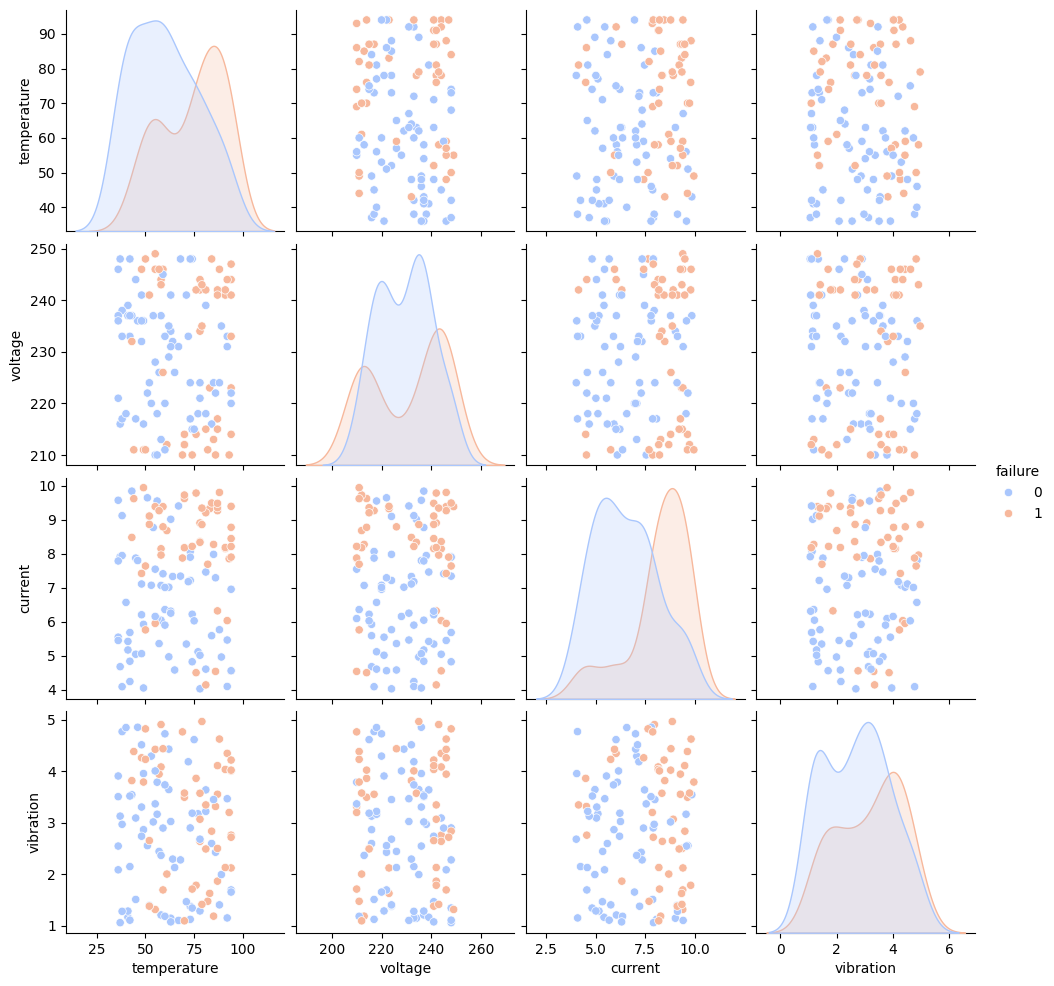

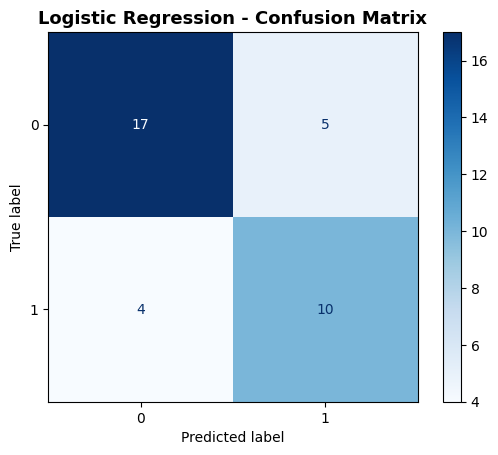

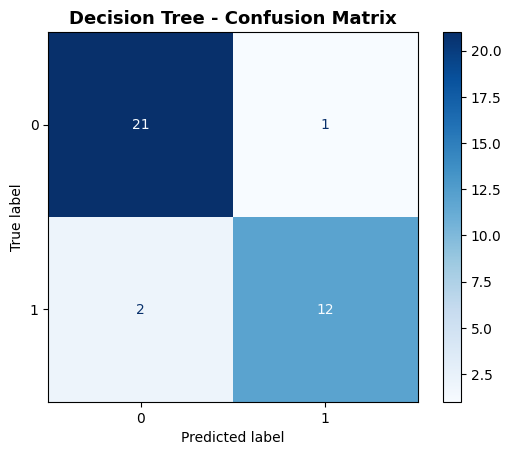

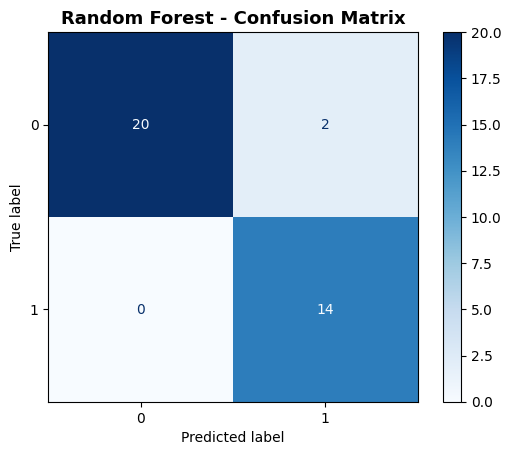


 MODEL COMPARISON 

                     Accuracy  Precision  Recall  F1 Score
Logistic Regression      0.75       0.67    0.71      0.69
Decision Tree            0.92       0.92    0.86      0.89
Random Forest            0.94       0.88    1.00      0.93


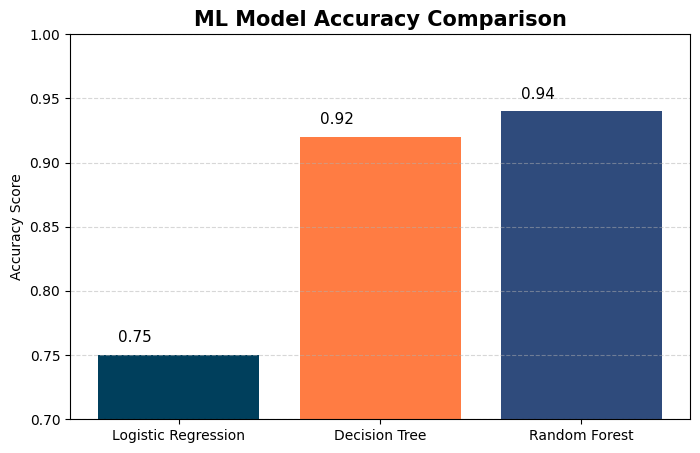

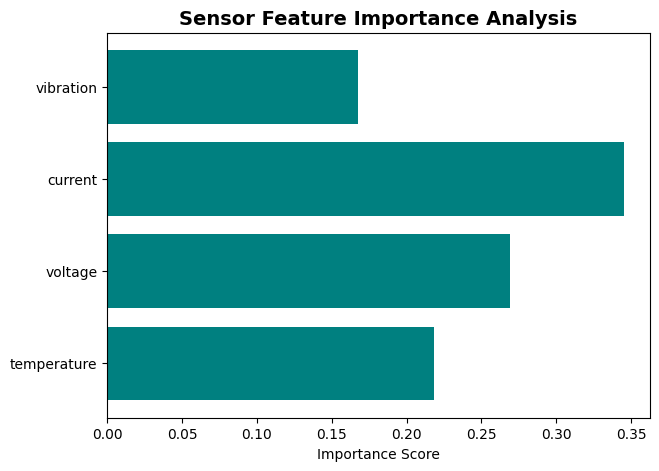


 Best Performing Model : Random Forest
 Accuracy : 0.94


In [ ]:
# =========================================================
# AI-Based Predictive Maintenance System
# for Smart Electronic Devices
# =========================================================

# -----------------------------
# IMPORT LIBRARIES
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================================================
# CREATE REALISTIC DATASET
# =========================================================

np.random.seed(42)

# Sensor values

temperature = np.random.randint(35, 95, 120)

voltage = np.random.randint(210, 250, 120)

current = np.random.uniform(4, 10, 120)

vibration = np.random.uniform(1, 5, 120)

# Failure Logic

failure = []

for t, v, c, vib in zip(
    temperature,
    voltage,
    current,
    vibration
):

    score = 0

    if t > 75:
        score += 1

    if v > 240 or v < 215:
        score += 1

    if c > 8:
        score += 1

    if vib > 3.8:
        score += 1

    # Device failure condition

    if score >= 2:
        failure.append(1)

    else:
        failure.append(0)

# Create DataFrame

df = pd.DataFrame({

    'temperature': temperature,

    'voltage': voltage,

    'current': current,

    'vibration': vibration,

    'failure': failure

})

# Save CSV File

df.to_csv("smart_device_data.csv", index=False)

print("\nDATASET PREVIEW\n")

print(df.head())

# =========================================================
# HEATMAP
# =========================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='YlGnBu',
    linewidths=1
)

plt.title(
    "Correlation Heatmap of Sensor Parameters",
    fontsize=14,
    fontweight='bold'
)

plt.show()

# =========================================================
# PAIR PLOT
# =========================================================

sns.pairplot(
    df,
    hue='failure',
    palette='coolwarm'
)

plt.show()

# =========================================================
# INPUT FEATURES / TARGET
# =========================================================

X = df[['temperature', 'voltage', 'current', 'vibration']]

y = df['failure']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# =========================================================
# MACHINE LEARNING MODELS
# =========================================================

models = {

    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
}

# =========================================================
# MODEL TRAINING & EVALUATION
# =========================================================

results = {}

for name, model in models.items():

    # Train model

    model.fit(X_train, y_train)

    # Predictions

    pred = model.predict(X_test)

    # Metrics

    results[name] = {

        "Accuracy":
            round(
                accuracy_score(y_test, pred),
                2
            ),

        "Precision":
            round(
                precision_score(y_test, pred),
                2
            ),

        "Recall":
            round(
                recall_score(y_test, pred),
                2
            ),

        "F1 Score":
            round(
                f1_score(y_test, pred),
                2
            )
    }

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap='Blues')

    plt.title(
        f"{name} - Confusion Matrix",
        fontsize=13,
        fontweight='bold'
    )

    plt.show()

# =========================================================
# RESULTS TABLE
# =========================================================

df_results = pd.DataFrame(results).T

print("\n==============================")
print(" MODEL COMPARISON ")
print("==============================\n")

print(df_results)

# =========================================================
# ACCURACY COMPARISON GRAPH
# =========================================================

plt.figure(figsize=(8,5))

bars = plt.bar(

    df_results.index,

    df_results['Accuracy'],

    color=[
        '#003f5c',
        '#ff7c43',
        '#2f4b7c'
    ]
)

plt.title(
    "ML Model Accuracy Comparison",
    fontsize=15,
    fontweight='bold'
)

plt.ylabel("Accuracy Score")

plt.ylim(0.7, 1.0)

# Accuracy values on bars

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + 0.1,
        yval + 0.01,
        round(yval, 2),
        fontsize=11
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

# =========================================================
# FEATURE IMPORTANCE ANALYSIS
# =========================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(7,5))

plt.barh(

    features,

    importance,

    color='teal'
)

plt.title(
    "Sensor Feature Importance Analysis",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Importance Score")

plt.show()

# =========================================================
# BEST MODEL
# =========================================================

best_model = df_results['Accuracy'].idxmax()

best_accuracy = df_results['Accuracy'].max()

print("\n====================================")

print(f" Best Performing Model : {best_model}")

print(f" Accuracy : {best_accuracy}")

print("====================================")
